<a href="https://colab.research.google.com/github/Md-Istiaq/Bilingual-Text-Spam-Detection-Model-Thesis/blob/main/Bilingual_Spam_Detection_Model_Useing_XLM_ROBERTa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup and Import Libraries

In [ ]:
# Install necessary packages
!pip install transformers
!pip install datasets
!pip install scikit-learn
!pip install matplotlib seaborn

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import XLMRobertaTokenizer, TFXLMRobertaForSequenceClassification, pipeline
import torch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 21.7 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.


# Load and Preprocess Data

In [ ]:
# Load dataset
df = pd.read_excel('Balanced_BanglaSpamData.xlsx')

# Display first few rows of the dataset
df.head()


,v1,v2
0,ham,আজকে brainstorming session arrange করেছি।
1,spam,আপনার জন্য দারুণ সুযোগ! কুইজে অংশগ্রহণ করুন এব...
2,ham,"I’ll get back to you after my meeting, এখন ব্য..."
3,spam,Fantasy Football খেলুন এবং Free Xiaomi Mi Band...
4,ham,"""Don't forget our meeting tomorrow. কালকের মিট..."


In [ ]:

import nltk
nltk.download('stopwords')

import re
from nltk.corpus import stopwords

# ... (rest of your code remains the same) ...
# Define Bangla stopwords
bangla_stopwords = [
    "অবশ্য", "অনেক", "অনেকে", "অনেকেই", "অন্তত", "অথবা", "অথচ", "অর্থাত", "অন্য", "আজ", "আছে",
    "আপনার", "আপনি", "আবার", "আমরা", "আমাকে", "আমাদের", "আমার", "আমি", "আরও", "আর", "আগে", "আগেই",
    "আই", "অতএব", "আগামী", "অবধি", "অনুযায়ী", "আদ্যভাগে", "এই", "একই", "একে", "একটি", "এখন", "এখনও",
    "এখানে", "এখানেই", "এটি", "এটা", "এটাই", "এতটাই", "এবং", "একবার", "এবার", "এদের", "এঁদের",
    "এমন", "এমনকী", "এল", "এর", "এরা", "এঁরা", "এস", "এত", "এতে", "এসে", "একে", "এ", "ঐ", "ই",
    "ইহা", "ইত্যাদি", "উনি", "উপর", "উপরে", "উচিত", "ও", "ওই", "ওর", "ওরা", "ওঁর", "ওঁরা", "ওকে",
    "ওদের", "ওঁদের", "ওখানে", "কত", "কবে", "করতে", "কয়েক", "কয়েকটি", "করবে", "করলেন", "করার", "কারও",
    "করা", "করি", "করিয়ে", "করার", "করাই", "করলে", "করলেন", "করিতে", "করিয়া", "করেছিলেন", "করছে",
    "করছেন", "করেছেন", "করেছে", "করেন", "করবেন", "করায়", "করে", "করেই", "কাছ", "কাছে", "কাজে", "কারণ",
    "কিছু", "কিছুই", "কিন্তু", "কিংবা", "কি", "কী", "কেউ", "কেউই", "কাউকে", "কেন", "কে", "কোনও", "কোনো",
    "কোন", "কখনও", "ক্ষেত্রে", "খুব", "গুলি", "গিয়ে", "গিয়েছে", "গেছে", "গেল", "গেলে", "গোটা", "চলে",
    "ছাড়া", "ছাড়াও", "ছিলেন", "ছিল", "জন্য", "জানা", "ঠিক", "তিনি", "তিনঐ", "তিনিও", "তখন", "তবে", "তবু",
    "তাঁদের", "তাঁাহারা", "তাঁরা", "তাঁর", "তাঁকে", "তাই", "তেমন", "তাকে", "তাহা", "তাহাতে", "তাহার",
    "তাদের", "তারপর", "তারা", "তারৈ", "তার", "তাহলে", "তিনি", "তা", "তাও", "তাতে", "তো", "তত", "তুমি",
    "তোমার", "তথা", "থাকে", "থাকা", "থাকায়", "থেকে", "থেকেও", "থাকবে", "থাকেন", "থাকবেন", "থেকেই", "দিকে",
    "দিতে", "দিয়ে", "দিয়েছে", "দিয়েছেন", "দিলেন", "দু", "দুটি", "দুটো", "দেয়", "দেওয়া", "দেওয়ার", "দেখা",
    "দেখে", "দেখতে", "দ্বারা", "ধরে", "ধরা", "নয়", "নানা", "না", "নাকি", "নাগাদ", "নিতে", "নিজে", "নিজেই",
    "নিজের", "নিজেদের", "নিয়ে", "নেওয়া", "নেওয়ার", "নেই", "নাই", "পক্ষে", "পর্যন্ত", "পাওয়া", "পারেন",
    "পারি", "পারে", "পরে", "পরেই", "পরেও", "পর", "পেয়ে", "প্রতি", "প্রভৃতি", "প্রায়", "ফের", "ফলে",
    "ফিরে", "ব্যবহার", "বলতে", "বললেন", "বলেছেন", "বলল", "বলা", "বলেন", "বলে", "বহু", "বসে", "বার",
    "বা", "বিনা", "বরং", "বদলে", "বাদে", "বার", "বিশেষ", "বিভিন্ন", "বিষয়টি", "ব্যবহার", "ব্যাপারে", "ভাবে",
    "ভাবেই", "মধ্যে", "মধ্যেই", "মধ্যেও", "মধ্যভাগে", "মাধ্যমে", "মাত্র", "মতো", "মতোই", "মোটেই", "যখন",
    "যদি", "যদিও", "যাবে", "যায়", "যাকে", "যাওয়া", "যাওয়ার", "যত", "যতটা", "যা", "যার", "যারা",
    "যাঁর", "যাঁরা", "যাদের", "যান", "যাচ্ছে", "যেতে", "যাতে", "যেন", "যেমন", "যেখানে", "যিনি", "যে",
    "রেখে", "রাখা", "রয়েছে", "রকম", "শুধু", "সঙ্গে", "সঙ্গেও", "সমস্ত", "সব", "সবার", "সহ", "সুতরাং",
    "সহিত", "সেই", "সেটা", "সেটি", "সেটাই", "সেটাও", "সম্প্রতি", "সেখান", "সেখানে", "সে", "স্পষ্ট", "স্বয়ং",
    "হইতে", "হইবে", "হৈলে", "হইয়া", "হচ্ছে", "হত", "হতে", "হতেই", "হবে", "হবেন", "হয়েছিল", "হয়েছে",
    "হয়েছেন", "হয়ে", "হয়নি", "হয়", "হয়েই", "হয়তো", "হল", "হলে", "হলেই", "হলেও", "হলো", "হিসাবে", "হওয়া",
    "হওয়ার", "হওয়ায়", "হন", "হোক", "জন", "জনকে", "জনের", "জানতে", "জানায়", "জানিয়ে", "জানানো", "জানিয়েছে",
    "জন্য", "জন্যওজে", "জে", "বেশ", "দেন", "তুলে", "ছিলেন", "চান", "চায়", "চেয়ে", "মোট", "যথেষ্ট", "টি"
]

def clean_text(text):
    # Remove punctuation and special characters
    text = re.sub(r'[^\w\s]', '', text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Convert to lowercase for English
    text = text.lower()
    # Combine Bangla and English stopwords
    stop_words = set(stopwords.words('english')) | set(bangla_stopwords)
    # Remove stopwords
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

# Apply text cleaning
df['cleaned_text'] = df['v2'].apply(clean_text)

# Display the dataset after cleaning
print(df.head())


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


     v1                                                 v2  \
0   ham          আজকে brainstorming session arrange করেছি।   
1  spam  আপনার জন্য দারুণ সুযোগ! কুইজে অংশগ্রহণ করুন এব...   
2   ham  I’ll get back to you after my meeting, এখন ব্য...   
3  spam  Fantasy Football খেলুন এবং Free Xiaomi Mi Band...   
4   ham  "Don't forget our meeting tomorrow. কালকের মিট...   

                                        cleaned_text  
0              আজক brainstorming session arrange করছ  
1  আপনর জনয দরণ সযগ কইজ অশগরহণ করন এব জতন টক কযশব...  
2                      ill get back meeting বযসত রয়ছ  
3  fantasy football খলন এব free xiaomi mi band জত...  
4       dont forget meeting tomorrow কলকর মট ভল যও ন  


# Split Data for Training and Evaluation

In [ ]:
# Split the dataset into train and test
X = df['cleaned_text']
y = df['v1'].map({'ham': 0, 'spam': 1})  # Assuming 'ham' = 0, 'spam' = 1

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the shape of the split data
print(f'Training data size: {len(X_train)}')
print(f'Test data size: {len(X_test)}')


Training data size: 1658
Test data size: 415


# Vectorization (TF-IDF)

In [ ]:
# Initialize TF-IDF vectorizer
tfidf = TfidfVectorizer(max_features=5000)

# Fit and transform the training data
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform the test data
X_test_tfidf = tfidf.transform(X_test)

# Check the shape of the transformed data
print(X_train_tfidf.shape, X_test_tfidf.shape)


(1658, 2615) (415, 2615)


# Choose and Train a Model (XLM-RoBERTa)

In [ ]:
# Load the pre-trained XLM-RoBERTa tokenizer and model
tokenizer = XLMRobertaTokenizer.from_pretrained('xlm-roberta-base')
model = TFXLMRobertaForSequenceClassification.from_pretrained('xlm-roberta-base', num_labels=2)


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

All PyTorch model weights were used when initializing TFXLMRobertaForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFXLMRobertaForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.dense.weight', 'classifier.dense.bias', 'classifier.out_proj.weight', 'classifier.out_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Load the pre-trained XLM-RoBERTa tokenizer and model (PyTorch version)
from transformers import XLMRobertaTokenizer, XLMRobertaForSequenceClassification, Trainer, TrainingArguments

tokenizer = XLMRobertaTokenizer.from_pretrained('xlm-roberta-base')
model = XLMRobertaForSequenceClassification.from_pretrained('xlm-roberta-base', num_labels=2)

# Tokenize the input data
def tokenize_function(texts):
    return tokenizer(texts, padding=True, truncation=True, return_tensors="pt", max_length=256)

train_encodings = tokenize_function(X_train.tolist())
test_encodings = tokenize_function(X_test.tolist())

# Prepare the dataset for PyTorch
class SpamDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels.iloc[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = SpamDataset(train_encodings, y_train)
test_dataset = SpamDataset(test_encodings, y_test)

# Initialize the TrainingArguments correctly without the 'framework' argument
training_args = TrainingArguments(
    output_dir='./results',          # output directory
    num_train_epochs=3,              # number of training epochs
    per_device_train_batch_size=8,   # batch size for training
    per_device_eval_batch_size=8,    # batch size for evaluation
    warmup_steps=500,                # number of warmup steps for learning rate scheduler
    weight_decay=0.01,               # strength of weight decay
    logging_dir='./logs',            # directory for storing logs
    logging_steps=10,
)

trainer = Trainer(
    model=model,                         # the instantiated 🤗 Transformers model to be trained
    args=training_args,                  # training arguments, defined above
    train_dataset=train_dataset,         # training dataset
    eval_dataset=test_dataset,           # evaluation dataset
)

# Train the model
trainer.train()


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:

 ··········


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


<ipython-input-18-a47205f679a2>:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


Step,Training Loss
10,0.715900
20,0.708100
30,0.696500
40,0.703200
50,0.692800
60,0.647000
70,0.527500
80,0.379900
90,0.227400
100,0.114100


<ipython-input-18-a47205f679a2>:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


TrainOutput(global_step=624, training_loss=0.18775875434370484, metrics={'train_runtime': 220.073, 'train_samples_per_second': 22.602, 'train_steps_per_second': 2.835, 'total_flos': 184037961003840.0, 'train_loss': 0.18775875434370484, 'epoch': 3.0})

# Evaluate the Model

In [ ]:
# Make predictions on the test set
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)

# Evaluate the results
print(classification_report(y_test, y_pred))


<ipython-input-18-a47205f679a2>:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


              precision    recall  f1-score   support

           0       1.00      0.97      0.98       211
           1       0.97      1.00      0.98       204

    accuracy                           0.98       415
   macro avg       0.98      0.98      0.98       415
weighted avg       0.98      0.98      0.98       415



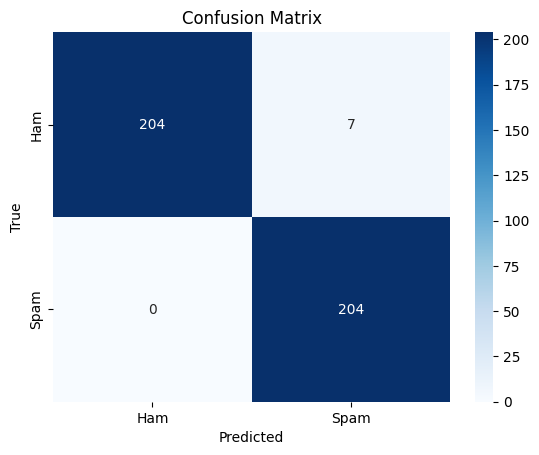

In [ ]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


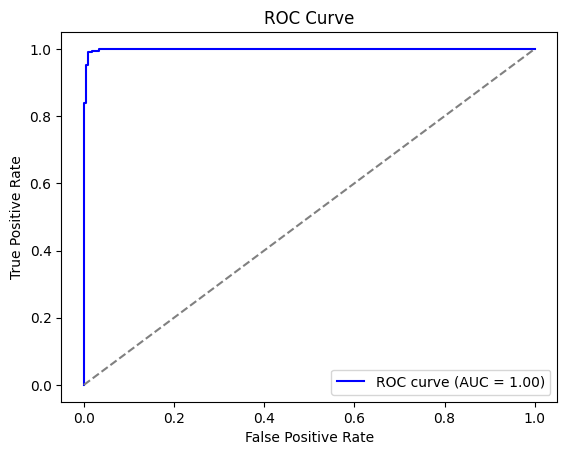

In [ ]:
# ROC AUC Curve
roc_auc = roc_auc_score(y_test, predictions.predictions[:, 1])
fpr, tpr, thresholds = roc_curve(y_test, predictions.predictions[:, 1])
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()




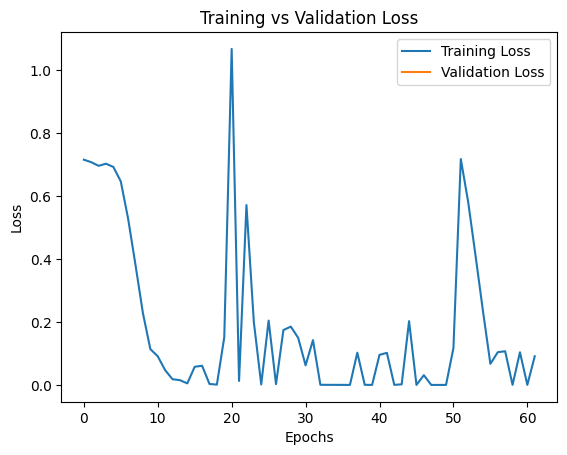

In [ ]:
# Validation Loss vs Training Loss
history = trainer.state.log_history
train_loss = [x['loss'] for x in history if 'loss' in x]
eval_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]
plt.plot(train_loss, label='Training Loss')
plt.plot(eval_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

# Save the Model

In [ ]:
# Save the model and tokenizer
model.save_pretrained("spam_model")
tokenizer.save_pretrained("spam_model")


('spam_model/tokenizer_config.json',
 'spam_model/special_tokens_map.json',
 'spam_model/sentencepiece.bpe.model',
 'spam_model/added_tokens.json')

# Make Predictions with the Model

In [ ]:
# Load the model and tokenizer for inference
# Use XLMRobertaForSequenceClassification
from transformers import XLMRobertaForSequenceClassification
model = XLMRobertaForSequenceClassification.from_pretrained("spam_model")
tokenizer = XLMRobertaTokenizer.from_pretrained("spam_model")

def predict(text):
    # Change return_tensors to 'pt' for PyTorch tensors
    encoding = tokenizer(text, return_tensors='pt', padding=True, truncation=True, max_length=256)
    output = model(**encoding)
    # Access logits directly and get the prediction
    prediction = torch.argmax(output.logits).item()
    return 'spam' if prediction == 1 else 'ham'

# Test prediction
test_text = "ক্রিকেট ও ফুটবলের ফ্যান্টাসি গেমস খেলুন 11 Players এ ! ক্লিক : https://11players.live/bd/ ; ট্যাক্সসহ চার্জ ৬.০৬ টাকা/দিন।"
print(predict(test_text))

spam


In [ ]:
# Test prediction
test_text = "খেললেই মিলবে টাকা! Kaun Banega Crorepati cutt.ly/ZeJ1b27g"
print(predict(test_text))

spam


In [ ]:
# Test prediction
test_text = "আজকের ক্লাসে অনেক কিছু শিখলাম, and it was very interactive. Let’s discuss it soon."
print(predict(test_text))

ham


In [ ]:
# Test prediction
test_text = "I’ve been thinking about our next steps, আমরা যদি কিছু পরিবর্তন করি, তা হবে আরও ভালো।"
print(predict(test_text))

ham


In [ ]:

# Test prediction
test_text = "তুমি কি গতকাল আমার মেসেজ পেয়েছিলে? Let me know if you need any help with your project."
print(predict(test_text))


ham
